KVASIR DATASET HYBRID VISION TRANSFORMER

DATA Visualization

c:\Users\Wall-E\.conda\envs\vakkas\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] Belirtilen yordam bulunamadı'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.1519828].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4831376].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8905448].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.91240

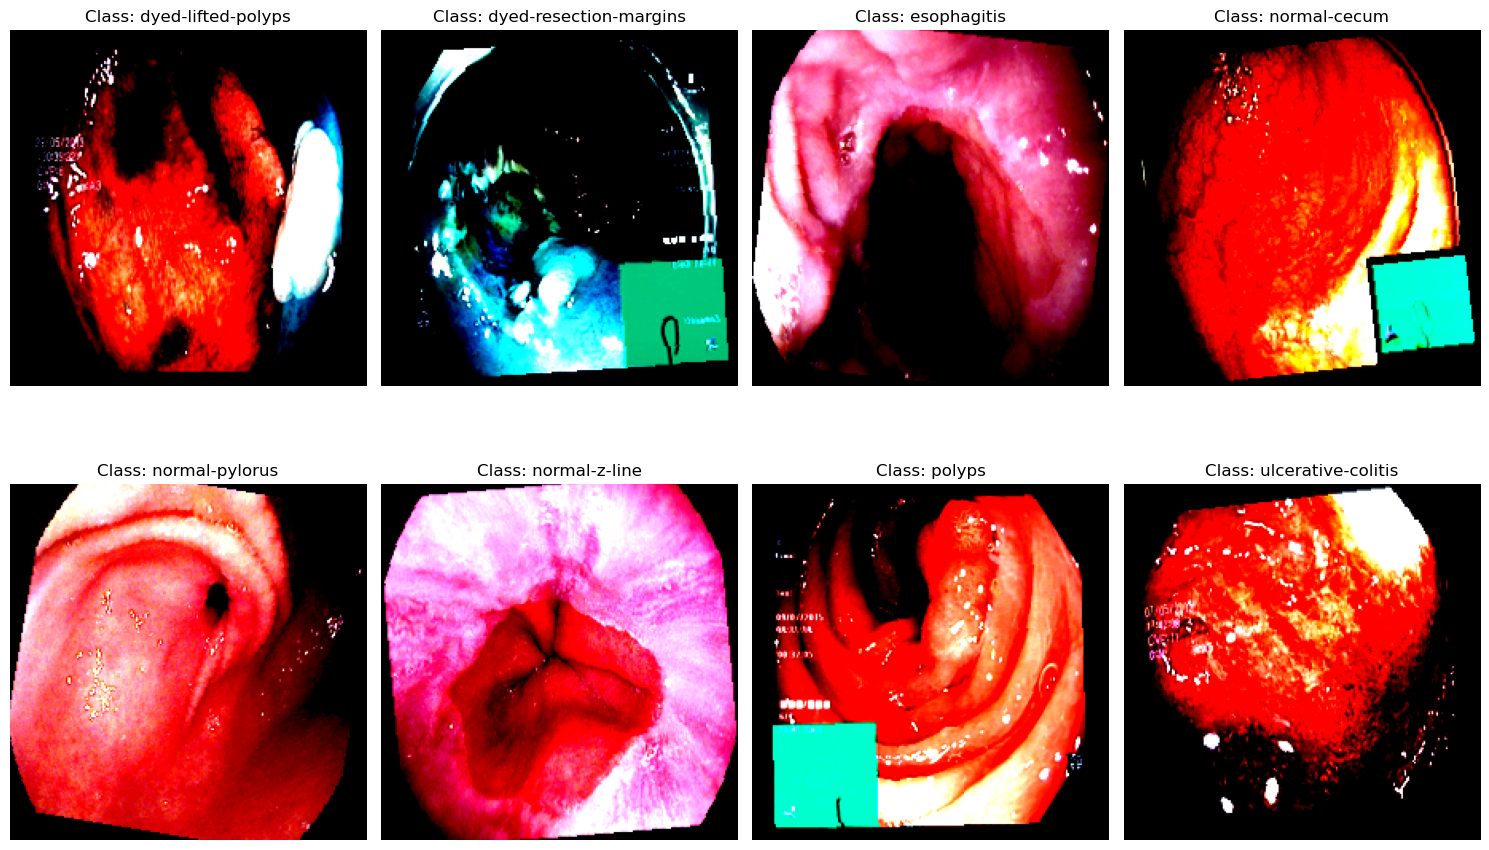

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import numpy as np
from torchvision import transforms 
from sklearn.model_selection import train_test_split
# Constants
DATASET_PATH = "kvasir-dataset-v2"  # Replace with your dataset path
IMG_SIZE = 224
BATCH_SIZE = 16
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data Augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Dataset
dataset = ImageFolder(DATASET_PATH, transform=transform)
num_classes = len(dataset.classes)

# Dataset Split
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.66, random_state=42)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

import matplotlib.pyplot as plt
import random

# Function to show one image from each class
def show_one_image_from_each_class(dataset, num_classes=8):
    class_to_idx = dataset.class_to_idx  # Mapping of class name to index
    idx_to_class = {v: k for k, v in class_to_idx.items()}  # Inverse mapping: index to class name

    # Prepare to plot images
    fig, axes = plt.subplots(2, 4, figsize=(15, 10))  # 2 rows, 4 columns
    axes = axes.flatten()  # Flatten to easily index the axes

    for i in range(num_classes):
        # Get all indices for the current class
        class_idx = i
        class_images = [idx for idx, label in enumerate(dataset.targets) if label == class_idx]
        
        # Randomly pick one image from this class
        random_image_idx = random.choice(class_images)
        image, label = dataset[random_image_idx]
        
        # Plot the image
        ax = axes[i]
        ax.imshow(image.permute(1, 2, 0).cpu())  # Convert from CxHxW to HxWxC for plt.imshow
        ax.axis('off')
        ax.set_title(f'Class: {idx_to_class[class_idx]}')
    
    plt.tight_layout()
    plt.show()

# Show one image from each class (8 classes in your dataset)
show_one_image_from_each_class(dataset, num_classes=8)

Hybrid Model: DenseNet201 + ViT Transformer

In [2]:
!pip install tensorflow-probability==0.20.0

In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from timm import create_model
import numpy as np
from sklearn.metrics import matthews_corrcoef
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import numpy as np
import pandas as pd
from itertools import cycle
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score


# Constants
DATASET_PATH = "kvasir-dataset-v2"  # Replace with your dataset path
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 25
LR = 0.001
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data Augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Dataset
dataset = ImageFolder(DATASET_PATH, transform=transform)
num_classes = len(dataset.classes)

# Dataset Split
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.66, random_state=42)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define Hybrid Model: DenseNet201 + Swin Transformer
class HybridDenseNetViT(nn.Module):
    def __init__(self, num_classes):
        super(HybridDenseNetViT, self).__init__()
        self.densenet = create_model('densenet201', pretrained=True, num_classes=num_classes)
        self.swin = create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
        self.fc = nn.Sequential(
            nn.Linear(2 * num_classes, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        densenet_features = self.densenet(x)
        swin_features = self.swin(x)
        combined_features = torch.cat((densenet_features, swin_features), dim=1)
        return self.fc(combined_features)


# Initialize Model
DenseNetViT = HybridDenseNetViT(num_classes)
DenseNetViT.to(DEVICE)

# Loss Function (Class-Balanced Loss)
class ClassBalancedLoss(nn.Module):
    def __init__(self, beta, num_classes):
        super(ClassBalancedLoss, self).__init__()
        self.beta = beta
        self.num_classes = num_classes
    
    def forward(self, logits, labels):
        class_counts = np.bincount(labels.cpu().numpy(), minlength=self.num_classes)
        class_counts = np.clip(class_counts, 1, None)  # Avoid division by zero
        effective_num = 1.0 - np.power(self.beta, class_counts)
        weights = (1.0 - self.beta) / (effective_num + 1e-8)
        weights = weights / np.sum(weights)
        weights = torch.tensor(weights, dtype=torch.float32).to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return loss

loss_fn = ClassBalancedLoss(beta=0.999, num_classes=num_classes)
optimizer = optim.AdamW(DenseNetViT.parameters(), lr=LR, weight_decay=1e-2)

# Training Function
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), 100.0 * correct / total

# Validation Function
def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    mcc = matthews_corrcoef(labels_list, preds_list)
    return total_loss / len(loader), 100.0 * correct / total, mcc

# Training Loop
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

# Training Loop
best_mcc = 0
for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(DenseNetViT, train_loader, optimizer, loss_fn, DEVICE)
    val_loss, val_acc, val_mcc = validate_epoch(DenseNetViT, val_loader, loss_fn, DEVICE)
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val MCC: {val_mcc:.4f}")
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_mcc > best_mcc:
        best_mcc = val_mcc
        torch.save(DenseNetViT.state_dict(), "best_densenet_vit_model.pth")
        print(f"Best model saved with MCC: {val_mcc:.4f}")


c:\Users\Wall-E\.conda\envs\vakkas\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 1/25


Validation: 100%|██████████| 51/51 [00:17<00:00,  2.85it/s]


Train Loss: 1.1479, Train Acc: 47.84%
Val Loss: 1.0243, Val Acc: 50.98%, Val MCC: 0.4690
Best model saved with MCC: 0.4690
Epoch 2/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.03it/s]


...

Train Loss: 0.2677, Train Acc: 87.93%
Val Loss: 0.3281, Val Acc: 88.97%, Val MCC: 0.8746
Epoch 24/25


Validation: 100%|██████████| 51/51 [00:17<00:00,  2.89it/s]


Train Loss: 0.2775, Train Acc: 87.16%
Val Loss: 0.3425, Val Acc: 85.17%, Val MCC: 0.8323
Epoch 25/25


Validation: 100%|██████████| 51/51 [00:17<00:00,  2.88it/s]

Train Loss: 0.2681, Train Acc: 87.75%
Val Loss: 0.3355, Val Acc: 88.73%, Val MCC: 0.8723


C:\Users\Wall-E\AppData\Local\Temp\ipykernel_29700\3797022620.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  DenseNetViT.load_state_dict(torch.load("best_densenet_vit_m

Test Loss: 0.3287, Test Acc: 87.69%, Test MCC: 0.8593


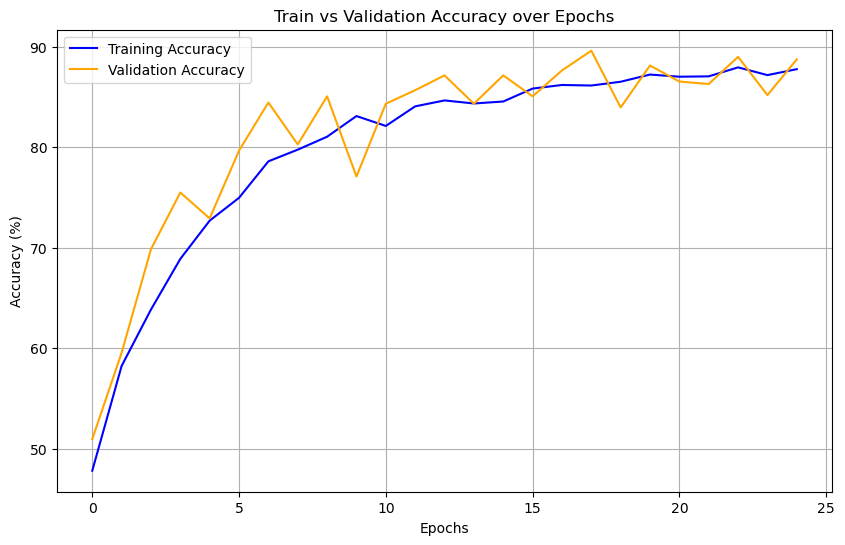

In [4]:
# Test the Model
DenseNetViT.load_state_dict(torch.load("best_densenet_vit_model.pth"))
test_loss, test_acc, test_mcc = validate_epoch(DenseNetViT, test_loader, loss_fn, DEVICE)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, Test MCC: {test_mcc:.4f}")
plt.figure(figsize=(10, 6))
plt.plot(history["train_acc"], label="Training Accuracy", color='blue')
plt.plot(history["val_acc"], label="Validation Accuracy", color='orange')
plt.title("Train vs Validation Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

Hybrid Model: ResNet50 + Vision Transformer

Epoch 1/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.04it/s]


Train Loss: 1.0825, Train Acc: 52.86%
Val Loss: 0.5844, Val Acc: 78.92%, Val MCC: 0.7620
Best model saved with MCC: 0.7620
Epoch 2/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.04it/s]


Train Loss: 0.5092, Train Acc: 78.09%
Val Loss: 0.3838, Val Acc: 85.78%, Val MCC: 0.8392
Best model saved with MCC: 0.8392
Epoch 3/25


...

Train Loss: 0.0768, Train Acc: 96.68%
Val Loss: 0.3417, Val Acc: 90.20%, Val MCC: 0.8898
Epoch 25/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.05it/s]
C:\Users\Wall-E\AppData\Local\Temp\ipykernel_29700\2235050096.py:154: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

Train Loss: 0.0809, Train Acc: 96.70%
Val Loss: 0.3531, Val Acc: 90.93%, Val MCC: 0.8970


Validation: 100%|██████████| 99/99 [00:33<00:00,  2.95it/s]

Test Loss: 0.2054, Test Acc: 91.86%, Test MCC: 0.9070


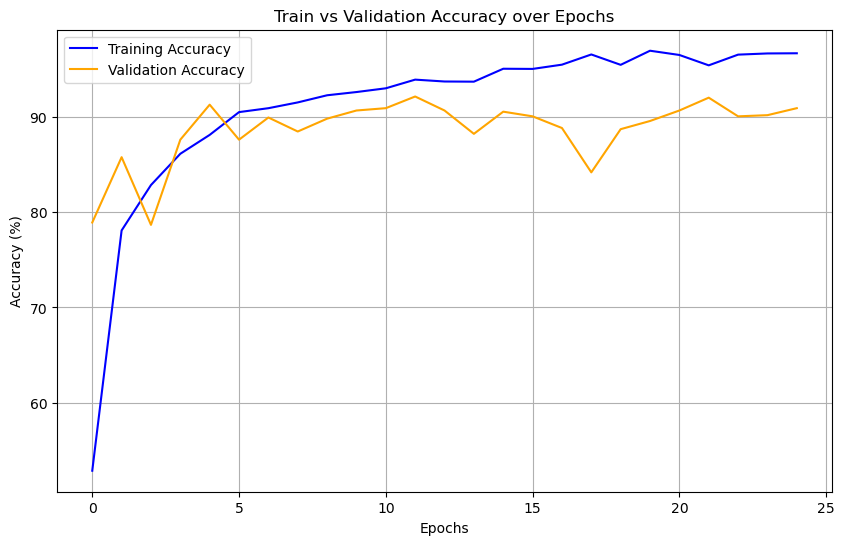

In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from timm import create_model
import numpy as np
from sklearn.metrics import matthews_corrcoef
from matplotlib import pyplot as plt

# Constants
DATASET_PATH = "kvasir-dataset-v2"  # Replace with your dataset path
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 25
LR = 0.001
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data Augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Dataset
dataset = ImageFolder(DATASET_PATH, transform=transform)
num_classes = len(dataset.classes)

# Dataset Split
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.66, random_state=42)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define Hybrid Model: ResNet50 + Vision Transformer
class HybridResNetViT(nn.Module):
    def __init__(self, num_classes):
        super(HybridResNetViT, self).__init__()
        self.resnet = create_model('resnet50', pretrained=True, num_classes=num_classes)
        self.vit = create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
        self.fc = nn.Sequential(
            nn.Linear(2 * num_classes, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        resnet_features = self.resnet(x)
        vit_features = self.vit(x)
        combined_features = torch.cat((resnet_features, vit_features), dim=1)
        return self.fc(combined_features)

# Initialize Model
ResNetViT = HybridResNetViT(num_classes)
ResNetViT.to(DEVICE)

# Loss Function (Class-Balanced Loss)
class ClassBalancedLoss(nn.Module):
    def __init__(self, beta, num_classes):
        super(ClassBalancedLoss, self).__init__()
        self.beta = beta
        self.num_classes = num_classes

    def forward(self, logits, labels):
        class_counts = np.bincount(labels.cpu().numpy(), minlength=self.num_classes)
        effective_num = 1.0 - np.power(self.beta, class_counts)
        weights = (1.0 - self.beta) / (effective_num + 1e-8)
        weights = weights / np.sum(weights)
        weights = torch.tensor(weights, dtype=torch.float32).to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return loss

loss_fn = ClassBalancedLoss(beta=0.999, num_classes=num_classes)
optimizer = optim.AdamW(ResNetViT.parameters(), lr=LR)

# Training and Validation Functions
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    mcc = matthews_corrcoef(labels_list, preds_list)
    return total_loss / len(loader), 100.0 * correct / total, mcc

# Training Loop
best_mcc = 0
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}
for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(ResNetViT, train_loader, optimizer, loss_fn, DEVICE)
    val_loss, val_acc, val_mcc = validate_epoch(ResNetViT, val_loader, loss_fn, DEVICE)
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val MCC: {val_mcc:.4f}")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    if val_mcc > best_mcc:
        best_mcc = val_mcc
        torch.save(ResNetViT.state_dict(), "best_resnet_vit_model.pth")
        print(f"Best model saved with MCC: {val_mcc:.4f}")

# Test the Model
ResNetViT.load_state_dict(torch.load("best_resnet_vit_model.pth"))
test_loss, test_acc, test_mcc = validate_epoch(ResNetViT, test_loader, loss_fn, DEVICE)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, Test MCC: {test_mcc:.4f}")
# Test the Model

plt.figure(figsize=(10, 6))
plt.plot(history["train_acc"], label="Training Accuracy", color='blue')
plt.plot(history["val_acc"], label="Validation Accuracy", color='orange')
plt.title("Train vs Validation Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()


Hybrid Model: InceptionV3 + ViT Transformer

Epoch 1/25


Validation: 100%|██████████| 51/51 [00:17<00:00,  2.92it/s]


Train Loss: 1.0766, Train Acc: 54.14%
Val Loss: 0.9861, Val Acc: 58.58%, Val MCC: 0.5347
Best model saved with MCC: 0.5347
Epoch 2/25


Validation: 100%|██████████| 51/51 [00:17<00:00,  2.89it/s]


Train Loss: 0.6973, Train Acc: 69.48%
Val Loss: 0.5710, Val Acc: 77.33%, Val MCC: 0.7413
Best model saved with MCC: 0.7413
Epoch 3/25


...

Train Loss: 0.2843, Train Acc: 87.64%
Val Loss: 0.2906, Val Acc: 87.99%, Val MCC: 0.8643
Epoch 25/25


Validation: 100%|██████████| 51/51 [00:17<00:00,  2.92it/s]


Train Loss: 0.2575, Train Acc: 88.84%
Val Loss: 0.2886, Val Acc: 89.58%, Val MCC: 0.8818
Best model saved with MCC: 0.8818


C:\Users\Wall-E\AppData\Local\Temp\ipykernel_29700\327452469.py:155: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  InceptionViT.load_state_dict(torch.load("best_inception_vi

Test Loss: 0.3070, Test Acc: 88.57%, Test MCC: 0.8702


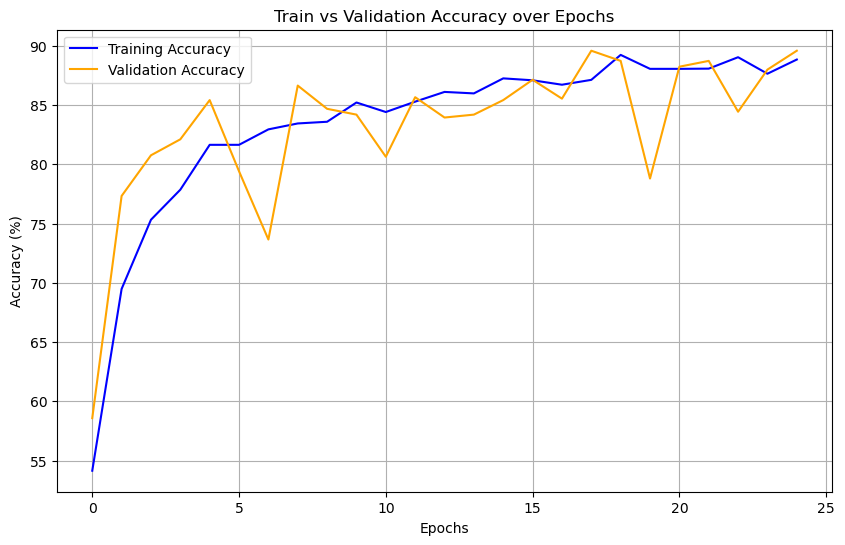

In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from timm import create_model
import numpy as np
from sklearn.metrics import matthews_corrcoef
from matplotlib import pyplot as plt

# Constants
DATASET_PATH = "kvasir-dataset-v2"  # Replace with your dataset path
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 25
LR = 0.001
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

# Data Augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Dataset
dataset = ImageFolder(DATASET_PATH, transform=transform)
num_classes = len(dataset.classes)

# Dataset Split
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.66, random_state=42)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define Hybrid Model: InceptionV3 + Vision Transformer
class HybridInceptionViT(nn.Module):
    def __init__(self, num_classes):
        super(HybridInceptionViT, self).__init__()
        self.inception = create_model('inception_v3', pretrained=True, num_classes=num_classes)
        self.vit = create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
        self.fc = nn.Sequential(
            nn.Linear(2 * num_classes, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        inception_features = self.inception(x)
        vit_features = self.vit(x)
        combined_features = torch.cat((inception_features, vit_features), dim=1)
        return self.fc(combined_features)

# Initialize Model
InceptionViT = HybridInceptionViT(num_classes)
InceptionViT.to(DEVICE)

# Loss Function (Class-Balanced Loss)
class ClassBalancedLoss(nn.Module):
    def __init__(self, beta, num_classes):
        super(ClassBalancedLoss, self).__init__()
        self.beta = beta
        self.num_classes = num_classes

    def forward(self, logits, labels):
        class_counts = np.bincount(labels.cpu().numpy(), minlength=self.num_classes)
        effective_num = 1.0 - np.power(self.beta, class_counts)
        weights = (1.0 - self.beta) / (effective_num + 1e-8)
        weights = weights / np.sum(weights)
        weights = torch.tensor(weights, dtype=torch.float32).to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return loss

loss_fn = ClassBalancedLoss(beta=0.999, num_classes=num_classes)
optimizer = optim.AdamW(InceptionViT.parameters(), lr=LR)

# Training and Validation Functions
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    mcc = matthews_corrcoef(labels_list, preds_list)
    return total_loss / len(loader), 100.0 * correct / total, mcc

# Training Loop
best_mcc = 0
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}
for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(InceptionViT, train_loader, optimizer, loss_fn, DEVICE)
    val_loss, val_acc, val_mcc = validate_epoch(InceptionViT, val_loader, loss_fn, DEVICE)
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val MCC: {val_mcc:.4f}")
    
     # Save the best model
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    if val_mcc > best_mcc:
        best_mcc = val_mcc
        torch.save(InceptionViT.state_dict(), "best_inception_vit_model.pth")
        print(f"Best model saved with MCC: {val_mcc:.4f}")

# Test the Model
InceptionViT.load_state_dict(torch.load("best_inception_vit_model.pth"))
test_loss, test_acc, test_mcc = validate_epoch(InceptionViT, test_loader, loss_fn, DEVICE)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, Test MCC: {test_mcc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(history["train_acc"], label="Training Accuracy", color='blue')
plt.plot(history["val_acc"], label="Validation Accuracy", color='orange')
plt.title("Train vs Validation Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

Hybrid Model: RegNet + Vision Transformer

Epoch 1/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.02it/s]


Train Loss: 0.8340, Train Acc: 62.98%
Val Loss: 0.4609, Val Acc: 81.00%, Val MCC: 0.7877
Best model saved with MCC: 0.7877
Epoch 2/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.01it/s]


Train Loss: 0.4565, Train Acc: 80.41%
Val Loss: 0.4747, Val Acc: 79.29%, Val MCC: 0.7747
Epoch 3/25


...

Train Loss: 0.1421, Train Acc: 93.88%
Val Loss: 0.2712, Val Acc: 91.91%, Val MCC: 0.9087
Best model saved with MCC: 0.9087
Epoch 25/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.04it/s]
C:\Users\Wall-E\AppData\Local\Temp\ipykernel_29700\4093598499.py:156: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

Train Loss: 0.1286, Train Acc: 94.38%
Val Loss: 0.3001, Val Acc: 90.56%, Val MCC: 0.8931


Validation: 100%|██████████| 99/99 [00:33<00:00,  2.94it/s]

Test Loss: 0.2884, Test Acc: 90.66%, Test MCC: 0.8941


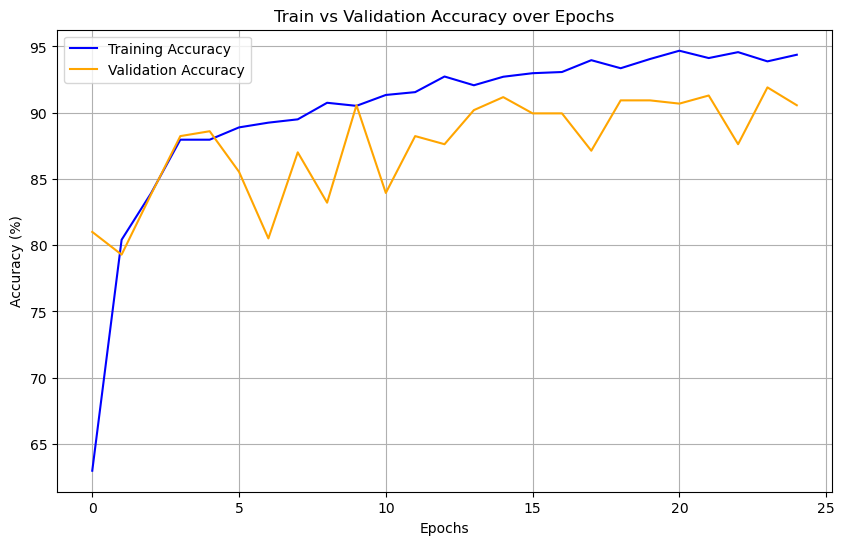

In [7]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from timm import create_model
import numpy as np
from sklearn.metrics import matthews_corrcoef
from matplotlib import pyplot as plt

# Constants RegNetSwin
DATASET_PATH = "kvasir-dataset-v2"  # Replace with your dataset path
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 25
LR = 0.001
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data Augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Dataset
dataset = ImageFolder(DATASET_PATH, transform=transform)
num_classes = len(dataset.classes)

# Dataset Split
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.66, random_state=42)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define Hybrid Model: RegNet + Swin Transformer
class HybridRegNetSwin(nn.Module):
    def __init__(self, num_classes):
        super(HybridRegNetSwin, self).__init__()
        self.regnet = create_model('regnety_032', pretrained=True, num_classes=num_classes)
        self.swin = create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)
        self.fc = nn.Sequential(
            nn.Linear(2 * num_classes, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        regnet_features = self.regnet(x)
        swin_features = self.swin(x)
        combined_features = torch.cat((regnet_features, swin_features), dim=1)
        return self.fc(combined_features)


# Initialize Model
RegNetSwin = HybridRegNetSwin(num_classes)
RegNetSwin.to(DEVICE)

# Loss Function (Class-Balanced Loss)
class ClassBalancedLoss(nn.Module):
    def __init__(self, beta, num_classes):
        super(ClassBalancedLoss, self).__init__()
        self.beta = beta
        self.num_classes = num_classes

    def forward(self, logits, labels):
        class_counts = np.bincount(labels.cpu().numpy(), minlength=self.num_classes)
        effective_num = 1.0 - np.power(self.beta, class_counts)
        weights = (1.0 - self.beta) / (effective_num + 1e-8)
        weights = weights / np.sum(weights)  # Normalize weights
        weights = torch.tensor(weights, dtype=torch.float32).to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return loss

loss_fn = ClassBalancedLoss(beta=0.999, num_classes=num_classes)
optimizer = optim.AdamW(RegNetSwin.parameters(), lr=LR)

# Training Function
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total

# Validation Function
def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    mcc = matthews_corrcoef(labels_list, preds_list)
    return total_loss / len(loader), 100.0 * correct / total, mcc

# Training Loop
best_mcc = 0
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}
for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(RegNetSwin, train_loader, optimizer, loss_fn, DEVICE)
    val_loss, val_acc, val_mcc = validate_epoch(RegNetSwin, val_loader, loss_fn, DEVICE)
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val MCC: {val_mcc:.4f}")

    # Save the best model
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    if val_mcc > best_mcc:
        best_mcc = val_mcc
        torch.save(RegNetSwin.state_dict(), "best_regnet_swin_model.pth")
        print(f"Best model saved with MCC: {val_mcc:.4f}")

# Test the Model
RegNetSwin.load_state_dict(torch.load("best_regnet_swin_model.pth"))
test_loss, test_acc, test_mcc = validate_epoch(RegNetSwin, test_loader, loss_fn, DEVICE)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, Test MCC: {test_mcc:.4f}")
plt.figure(figsize=(10, 6))
plt.plot(history["train_acc"], label="Training Accuracy", color='blue')
plt.plot(history["val_acc"], label="Validation Accuracy", color='orange')
plt.title("Train vs Validation Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

Hybrid Model: MobileNetV2 + Vision Transformer

Epoch 1/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.07it/s]


Train Loss: 0.7118, Train Acc: 71.95%
Val Loss: 0.4853, Val Acc: 83.82%, Val MCC: 0.8172
Best model saved with MCC: 0.8172
Epoch 2/25


Validation: 100%|██████████| 51/51 [00:17<00:00,  2.99it/s]


Train Loss: 0.4107, Train Acc: 82.96%
Val Loss: 0.3590, Val Acc: 86.76%, Val MCC: 0.8501
Best model saved with MCC: 0.8501
Epoch 3/25


...

Train Loss: 0.1529, Train Acc: 93.21%
Val Loss: 0.2506, Val Acc: 88.97%, Val MCC: 0.8765
Epoch 25/25


Validation: 100%|██████████| 51/51 [00:16<00:00,  3.06it/s]


Train Loss: 0.1283, Train Acc: 94.57%
Val Loss: 0.2649, Val Acc: 91.18%, Val MCC: 0.8996
Best model saved with MCC: 0.8996


C:\Users\Wall-E\AppData\Local\Temp\ipykernel_29700\2073932821.py:154: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  MobileNetViT.load_state_dict(torch.load("best_mobilenet_v

Test Loss: 0.2376, Test Acc: 91.79%, Test MCC: 0.9063


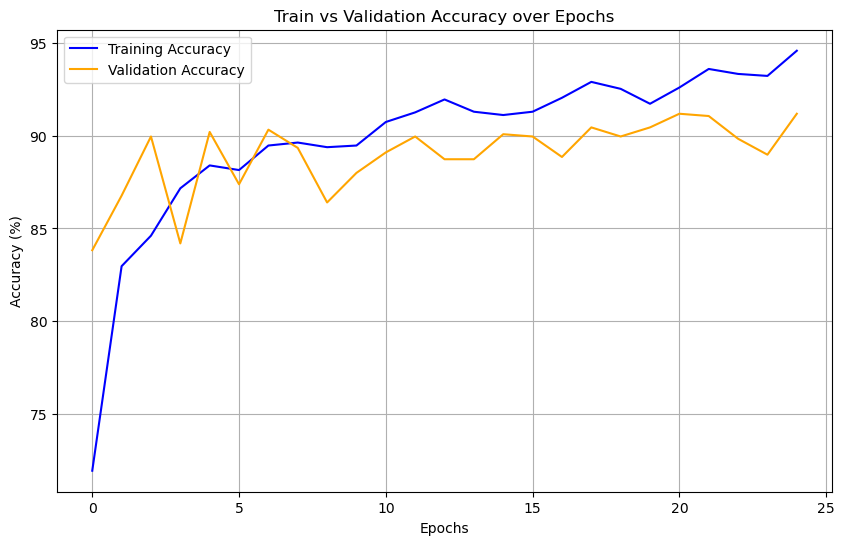

In [8]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from timm import create_model
import numpy as np
from sklearn.metrics import matthews_corrcoef
from matplotlib import pyplot as plt

# Constants
DATASET_PATH = "kvasir-dataset-v2"  # Replace with your dataset path
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 25
LR = 0.001
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data Augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Dataset
dataset = ImageFolder(DATASET_PATH, transform=transform)
num_classes = len(dataset.classes)

# Dataset Split
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.66, random_state=42)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define Hybrid Model: MobileNetV2 + Vision Transformer
class HybridMobileNetViT(nn.Module):
    def __init__(self, num_classes):
        super(HybridMobileNetViT, self).__init__()
        self.mobilenet = create_model('mobilenetv2_100', pretrained=True, num_classes=num_classes)
        self.vit = create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
        self.fc = nn.Sequential(
            nn.Linear(2 * num_classes, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        mobilenet_features = self.mobilenet(x)
        vit_features = self.vit(x)
        combined_features = torch.cat((mobilenet_features, vit_features), dim=1)
        return self.fc(combined_features)

# Initialize Model
MobileNetViT = HybridMobileNetViT(num_classes)
MobileNetViT.to(DEVICE)

# Loss Function (Class-Balanced Loss)
class ClassBalancedLoss(nn.Module):
    def __init__(self, beta, num_classes):
        super(ClassBalancedLoss, self).__init__()
        self.beta = beta
        self.num_classes = num_classes

    def forward(self, logits, labels):
        class_counts = np.bincount(labels.cpu().numpy(), minlength=self.num_classes)
        effective_num = 1.0 - np.power(self.beta, class_counts)
        weights = (1.0 - self.beta) / (effective_num + 1e-8)
        weights = weights / np.sum(weights)
        weights = torch.tensor(weights, dtype=torch.float32).to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return loss

loss_fn = ClassBalancedLoss(beta=0.999, num_classes=num_classes)
optimizer = optim.AdamW(MobileNetViT.parameters(), lr=LR)

# Training and Validation Functions
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    mcc = matthews_corrcoef(labels_list, preds_list)
    return total_loss / len(loader), 100.0 * correct / total, mcc

# Training Loop
best_mcc = 0
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}
for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(MobileNetViT, train_loader, optimizer, loss_fn, DEVICE)
    val_loss, val_acc, val_mcc = validate_epoch(MobileNetViT, val_loader, loss_fn, DEVICE)
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val MCC: {val_mcc:.4f}")
    if val_mcc > best_mcc:
        best_mcc = val_mcc
        torch.save(MobileNetViT.state_dict(), "best_mobilenet_vit_model.pth")
        print(f"Best model saved with MCC: {val_mcc:.4f}")
     
     # Save the best model
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

# Test the Model
MobileNetViT.load_state_dict(torch.load("best_mobilenet_vit_model.pth"))
test_loss, test_acc, test_mcc = validate_epoch(MobileNetViT, test_loader, loss_fn, DEVICE)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, Test MCC: {test_mcc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(history["train_acc"], label="Training Accuracy", color='blue')
plt.plot(history["val_acc"], label="Validation Accuracy", color='orange')
plt.title("Train vs Validation Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

Choosing the best Model

In [9]:
import numpy as np
from collections import Counter
from torch.utils.data import DataLoader
# Assuming the other models are implemented similarly to HybridSwinResNet
models = [DenseNetViT, ResNetViT, InceptionViT, RegNetViT, MobileNetViT]  # Replace with your actual model objects

def get_model_predictions(model, dataloader, device):
    """
    Get predictions for all images in the test dataloader using a given model.
    """
    model.eval()
    predictions = []
    with torch.no_grad():
        for images, _ in dataloader:  # Labels are not needed for prediction
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)  # Get class predictions
            predictions.extend(preds.cpu().numpy())
    return predictions

def majority_vote(all_predictions):
    """
    Perform majority voting across predictions from all models for each image.
    """
    final_predictions = []
    for preds in zip(*all_predictions):  # Iterate through predictions for each image
        vote = Counter(preds).most_common(1)[0][0]  # Get the class with the highest votes
        final_predictions.append(vote)
    return np.array(final_predictions)

# Test the models and perform majority voting
def evaluate_with_voting(models, test_dataloader, device):
    """
    Evaluate the test dataset using all models and perform majority voting for final predictions.
    """
    # Collect predictions from all models
    all_model_predictions = []
    for model in models:
        predictions = get_model_predictions(model, test_dataloader, device)
        all_model_predictions.append(predictions)

    # Perform majority voting
    final_predictions = majority_vote(all_model_predictions)
    return all_model_predictions, final_predictions

# Test DataLoader
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Evaluate models and perform voting
all_model_predictions, final_predictions = evaluate_with_voting(models, test_dataloader, DEVICE)

# Display results for each test image
for i, (image, _) in enumerate(test_dataset):  # Assuming test_dataset is an instance of Subset
    print(f"Image {i+1}:")
    for model_idx, predictions in enumerate(all_model_predictions):
        print(f"  Model {model_idx + 1} prediction: Class {predictions[i]}")
    print(f"  Final voted class: Class {final_predictions[i]}")

NameError: name 'RegNetViT' is not defined

Confusion matrix

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import DataLoader

# Assuming the other models are implemented similarly to HybridSwinResNet
models = [DenseNetViT, ResNetViT, InceptionViT, RegNetViT, MobileNetViT]  # Replace with your actual model objects

def get_model_predictions(model, dataloader, device):
    """
    Get predictions for all images in the test dataloader using a given model.
    """
    model.eval()
    predictions = []
    with torch.no_grad():
        for images, _ in dataloader:  # Labels are not needed for prediction
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)  # Get class predictions
            predictions.extend(preds.cpu().numpy())
    return predictions

def majority_vote(all_predictions):
    """
    Perform majority voting across predictions from all models for each image.
    """
    final_predictions = []
    for preds in zip(*all_predictions):  # Iterate through predictions for each image
        vote = Counter(preds).most_common(1)[0][0]  # Get the class with the highest votes
        final_predictions.append(vote)
    return np.array(final_predictions)

def evaluate_with_voting(models, test_dataloader, device):
    """
    Evaluate the test dataset using all models and perform majority voting for final predictions.
    """
    # Collect predictions from all models
    all_model_predictions = []
    for model in models:
        predictions = get_model_predictions(model, test_dataloader, device)
        all_model_predictions.append(predictions)

    # Perform majority voting
    final_predictions = majority_vote(all_model_predictions)
    return all_model_predictions, final_predictions

# Graph visualization
def plot_results(all_model_predictions, final_predictions, test_dataset):
    """
    Plot a graph showing predictions from each model and the final voting results.
    """
    num_images = len(test_dataset)
    x = np.arange(num_images)  # Image indices

    plt.figure(figsize=(12, 6))

    # Plot predictions from each model
    for i, model_predictions in enumerate(all_model_predictions):
        plt.plot(x, model_predictions, label=f"Model {i + 1} Predictions", alpha=0.7)

    # Plot final voting results
    plt.plot(x, final_predictions, label="Final Voted Class", linewidth=2, linestyle='--', color='black')

    plt.xlabel("Image Index")
    plt.ylabel("Predicted Class")
    plt.title("Model Predictions and Final Voted Class for Test Images")
    plt.legend()
    plt.grid(True)
    plt.show()

# Test DataLoader
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Evaluate models and perform voting
all_model_predictions, final_predictions = evaluate_with_voting(models, test_dataloader, DEVICE)

# Plot the results
plot_results(all_model_predictions, final_predictions, test_dataset)